In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load training data only
train_df = pd.read_parquet("../artifacts/03_train.parquet")

# Folder for EDA charts
eda_dir = Path("../artifacts/eda")
eda_dir.mkdir(parents=True, exist_ok=True)

print("Training data shape:", train_df.shape)
print("Columns:")
print(train_df.columns.tolist())

Matplotlib is building the font cache; this may take a moment.


Training data shape: (67533, 15)
Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_zip_code_prefix_x', 'customer_city_x', 'customer_state_x', 'customer_zip_code_prefix_y', 'customer_city_y', 'customer_state_y', 'late_delivery']


In [2]:
train_df.info()

print("\nMemory usage (MB):")
print(round(train_df.memory_usage(deep=True).sum() / 1024**2, 2))

print("\nFirst 5 rows:")
display(train_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 67533 entries, 0 to 67532
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       67533 non-null  str           
 1   customer_id                    67533 non-null  str           
 2   order_status                   67533 non-null  str           
 3   order_purchase_timestamp       67533 non-null  datetime64[us]
 4   order_approved_at              67522 non-null  datetime64[us]
 5   order_delivered_carrier_date   67532 non-null  datetime64[us]
 6   order_delivered_customer_date  67533 non-null  datetime64[us]
 7   order_estimated_delivery_date  67533 non-null  datetime64[us]
 8   customer_zip_code_prefix_x     67533 non-null  int64         
 9   customer_city_x                67533 non-null  str           
 10  customer_state_x               67533 non-null  str           
 11  customer_zip_code_prefix_y

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix_x,customer_city_x,customer_state_x,customer_zip_code_prefix_y,customer_city_y,customer_state_y,late_delivery
0,690a2092d1bf37549b9850423615d32a,761a4cbfcebc07e915349e3aee6db335,delivered,2018-06-20 19:25:54,2018-06-20 19:57:54,2018-06-21 12:24:00,2018-06-25 17:23:23,2018-07-13,85930,nova santa rosa,PR,85930,nova santa rosa,PR,0
1,af7d0849149bec7653f157d2a28d1f6d,50f88b1c1d1f4fec543bea69952deef2,delivered,2017-09-21 20:33:31,2017-09-21 20:44:18,2017-09-25 20:13:33,2017-10-04 19:11:38,2017-10-18,43700,simoes filho,BA,43700,simoes filho,BA,0
2,389ac865e327bd982cf1101e0a77ff34,5ab6da4f0948f2079320f3ab48f44c5d,delivered,2018-07-06 21:06:43,2018-07-06 21:30:54,2018-07-10 11:21:00,2018-07-13 23:58:32,2018-07-30,38110,agua comprida,MG,38110,agua comprida,MG,0
3,214cc0f5b3a0461874dbbc915258bb54,bb0a7e8931e8e578f7bee85722bf921f,delivered,2018-06-16 17:02:59,2018-06-17 17:12:31,2018-06-19 12:28:00,2018-06-22 14:11:41,2018-07-12,13857,estiva gerbi,SP,13857,estiva gerbi,SP,0
4,5834f2a1c94daee3cda85aa62af0a929,05d6dccf0ec00ec89c4462f9925903e1,delivered,2018-08-16 16:04:57,2018-08-16 16:15:32,2018-08-20 17:10:00,2018-08-22 17:32:30,2018-08-21,3612,sao paulo,SP,3612,sao paulo,SP,1


In [3]:
missing_summary = pd.DataFrame(
    {
        "missing_count": train_df.isna().sum(),
        "missing_percent": (train_df.isna().mean() * 100).round(2),
    }
)

missing_summary = missing_summary.sort_values("missing_percent", ascending=False)

display(missing_summary)

,missing_count,missing_percent
order_approved_at,11,0.02
customer_id,0,0.00
order_id,0,0.00
order_status,0,0.00
order_purchase_timestamp,0,0.00
order_delivered_carrier_date,1,0.00
order_delivered_customer_date,0,0.00
order_estimated_delivery_date,0,0.00
customer_zip_code_prefix_x,0,0.00
customer_city_x,0,0.00


In [4]:
numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()

# Exclude the target from feature statistics
numeric_features = [col for col in numeric_cols if col != "late_delivery"]

numeric_summary = train_df[numeric_features].describe().T
numeric_summary["skew"] = train_df[numeric_features].skew()
numeric_summary["missing_percent"] = (
    train_df[numeric_features].isna().mean() * 100
).round(2)

display(numeric_summary.round(2))

,count,mean,std,min,25%,50%,75%,max,skew,missing_percent
customer_zip_code_prefix_x,67533.0,35123.19,29794.17,1003.0,11346.0,24422.0,58890.0,99965.0,0.78,0.0
customer_zip_code_prefix_y,67533.0,35123.19,29794.17,1003.0,11346.0,24422.0,58890.0,99965.0,0.78,0.0


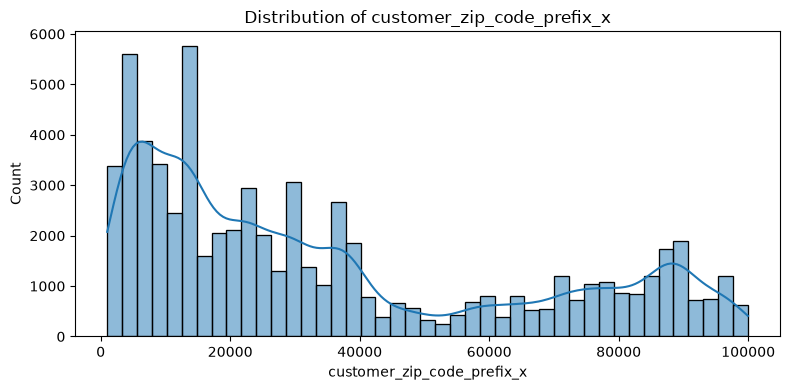

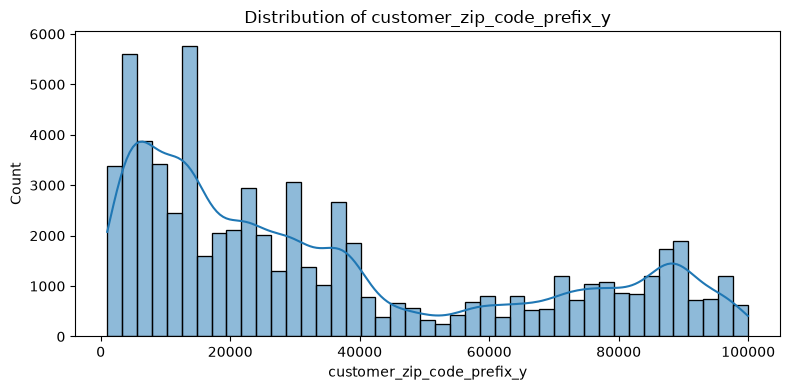

In [6]:
plot_cols = [col for col in numeric_features if col not in ["customer_zip_code_prefix"]]

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=train_df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

    plt.savefig(eda_dir / f"distribution_{col}.png")
    plt.show()
    plt.close()

In [9]:
outlier_rows = []

for col in plot_cols:
    series = train_df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((series < lower) | (series > upper)).sum()

    outlier_rows.append(
        {
            "feature": col,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(outlier_count),
            "outlier_percent": round(outlier_count / len(series) * 100, 2),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary.sort_values("outlier_percent", ascending=False))

,feature,lower_bound,upper_bound,outlier_count,outlier_percent
0,customer_zip_code_prefix_x,-59970.0,130206.0,0,0.0
1,customer_zip_code_prefix_y,-59970.0,130206.0,0,0.0


In [12]:
categorical_cols = train_df.select_dtypes(
    include=["object", "str", "category", "bool"]
).columns.tolist()

categorical_summary = pd.DataFrame(
    {
        "unique_values": train_df[categorical_cols].nunique(dropna=True),
        "missing_count": train_df[categorical_cols].isna().sum(),
        "missing_percent": (train_df[categorical_cols].isna().mean() * 100).round(2),
    }
).sort_values("unique_values", ascending=False)

display(categorical_summary)

,unique_values,missing_count,missing_percent
order_id,67533,0,0.0
customer_id,67533,0,0.0
customer_city_x,3650,0,0.0
customer_city_y,3650,0,0.0
customer_state_x,27,0,0.0
customer_state_y,27,0,0.0
order_status,2,0,0.0


In [13]:
for col in categorical_cols:
    print(f"\n{col} — top 10 values")
    display(
        train_df[col].value_counts(dropna=False).head(10).rename("count").to_frame()
    )


order_id — top 10 values


,count
order_id,
690a2092d1bf37549b9850423615d32a,1
af7d0849149bec7653f157d2a28d1f6d,1
389ac865e327bd982cf1101e0a77ff34,1
214cc0f5b3a0461874dbbc915258bb54,1
5834f2a1c94daee3cda85aa62af0a929,1
f55227c04af301a96c2c22eb6973d8e8,1
0a020ef040e4b3065551bb31e0aca1cd,1
ad263bc9111c1e0cbb780c4b7c1009e6,1
2b60eebc028bc36dca9f731556d1581f,1



customer_id — top 10 values


,count
customer_id,
761a4cbfcebc07e915349e3aee6db335,1
50f88b1c1d1f4fec543bea69952deef2,1
5ab6da4f0948f2079320f3ab48f44c5d,1
bb0a7e8931e8e578f7bee85722bf921f,1
05d6dccf0ec00ec89c4462f9925903e1,1
49896c657941c4194e824df727d59d6b,1
d06d4e2d7fba05929a9efc2721bb1d82,1
990bde3076343bfd17ad481ad171ba5e,1
3781d7c24d2229264855dfb1f859cf81,1



order_status — top 10 values


...

,count
customer_state_x,
SP,28380
RJ,8648
MG,8013
RS,3738
PR,3486
SC,2399
BA,2279
DF,1444
ES,1386



customer_city_y — top 10 values


,count
customer_city_y,
sao paulo,10555
rio de janeiro,4647
belo horizonte,1915
brasilia,1438
curitiba,1068
campinas,1011
porto alegre,932
salvador,833
guarulhos,813



customer_state_y — top 10 values


,count
customer_state_y,
SP,28380
RJ,8648
MG,8013
RS,3738
PR,3486
SC,2399
BA,2279
DF,1444
ES,1386


,count
late_delivery,
On-time,62054
Late,5479


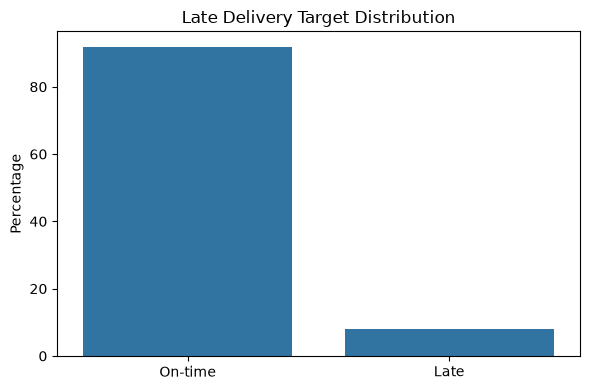

In [14]:
target_counts = train_df["late_delivery"].value_counts().sort_index()

display(target_counts.rename(index={0: "On-time", 1: "Late"}).to_frame("count"))

target_percent = (
    train_df["late_delivery"].value_counts(normalize=True).sort_index().mul(100)
)

plt.figure(figsize=(6, 4))
sns.barplot(x=["On-time", "Late"], y=target_percent.values)
plt.ylabel("Percentage")
plt.title("Late Delivery Target Distribution")
plt.tight_layout()
plt.savefig(eda_dir / "target_distribution.png")
plt.show()
plt.close()


Late-delivery rate by order_status


,count,late_rate
order_status,,
delivered,67529,8.11


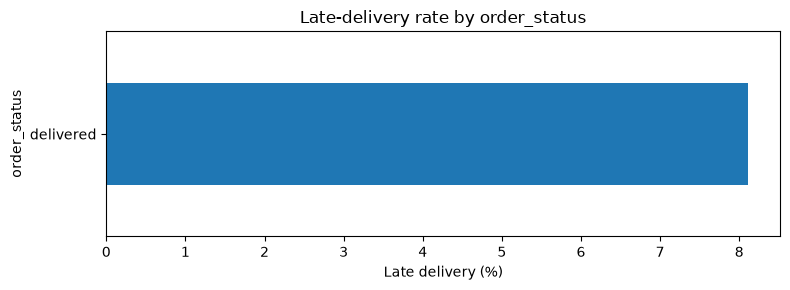


Late-delivery rate by customer_state_x


,count,late_rate
customer_state_x,,
AL,269,24.16
MA,502,19.72
PI,333,16.22
CE,890,15.96
SE,243,15.64
BA,2279,14.00
RJ,8648,13.60
ES,1386,12.27
MS,475,12.00


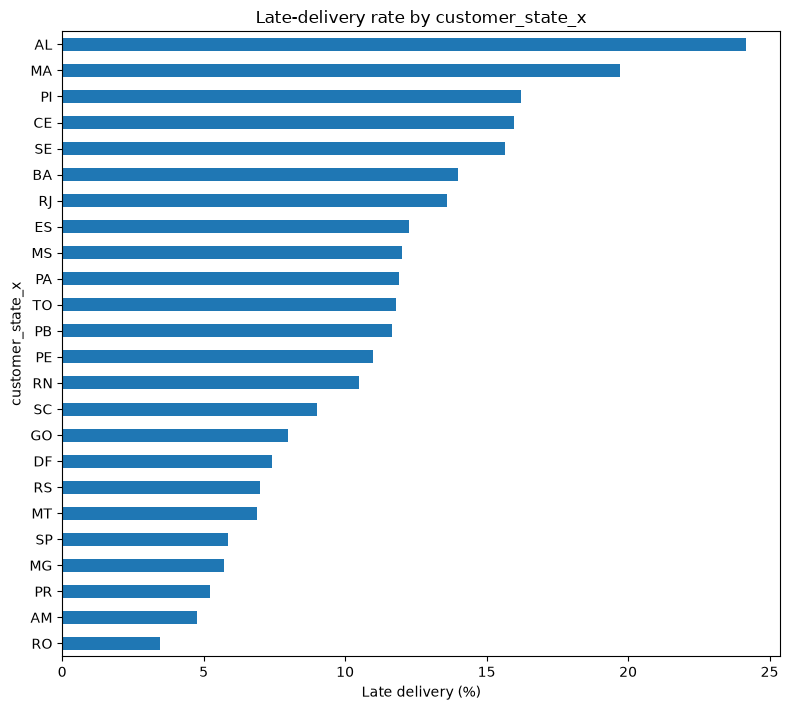


Late-delivery rate by customer_state_y


,count,late_rate
customer_state_y,,
AL,269,24.16
MA,502,19.72
PI,333,16.22
CE,890,15.96
SE,243,15.64
BA,2279,14.00
RJ,8648,13.60
ES,1386,12.27
MS,475,12.00


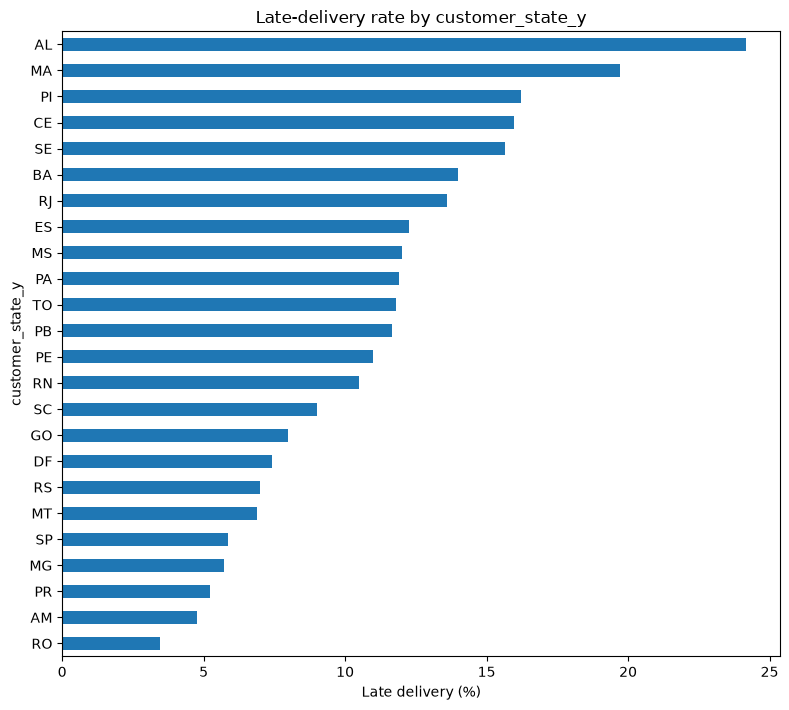

In [16]:
id_cols = ["order_id", "customer_id"]

analysis_cats = [
    col
    for col in categorical_cols
    if col not in id_cols and train_df[col].nunique(dropna=True) <= 30
]

for col in analysis_cats:
    grouped = (
        train_df.groupby(col, dropna=False)["late_delivery"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "late_rate"})
    )

    grouped["late_rate"] = (grouped["late_rate"] * 100).round(2)
    grouped = grouped[grouped["count"] >= 100]

    print(f"\nLate-delivery rate by {col}")
    display(grouped.sort_values("late_rate", ascending=False))

    if not grouped.empty:
        grouped["late_rate"].sort_values().plot(
            kind="barh", figsize=(8, max(3, len(grouped) * 0.3))
        )
        plt.xlabel("Late delivery (%)")
        plt.title(f"Late-delivery rate by {col}")
        plt.tight_layout()
        plt.savefig(eda_dir / f"late_rate_{col}.png")
        plt.show()
        plt.close()

In [17]:
for col in plot_cols:
    grouped = (
        train_df.groupby("late_delivery")[col].agg(["count", "mean", "median"]).round(2)
    )

    print(f"\n{col} by late_delivery")
    display(grouped)


customer_zip_code_prefix_x by late_delivery


,count,mean,median
late_delivery,,,
0,62054,34918.20,24120.0
1,5479,37444.92,28625.0



customer_zip_code_prefix_y by late_delivery


,count,mean,median
late_delivery,,,
0,62054,34918.20,24120.0
1,5479,37444.92,28625.0


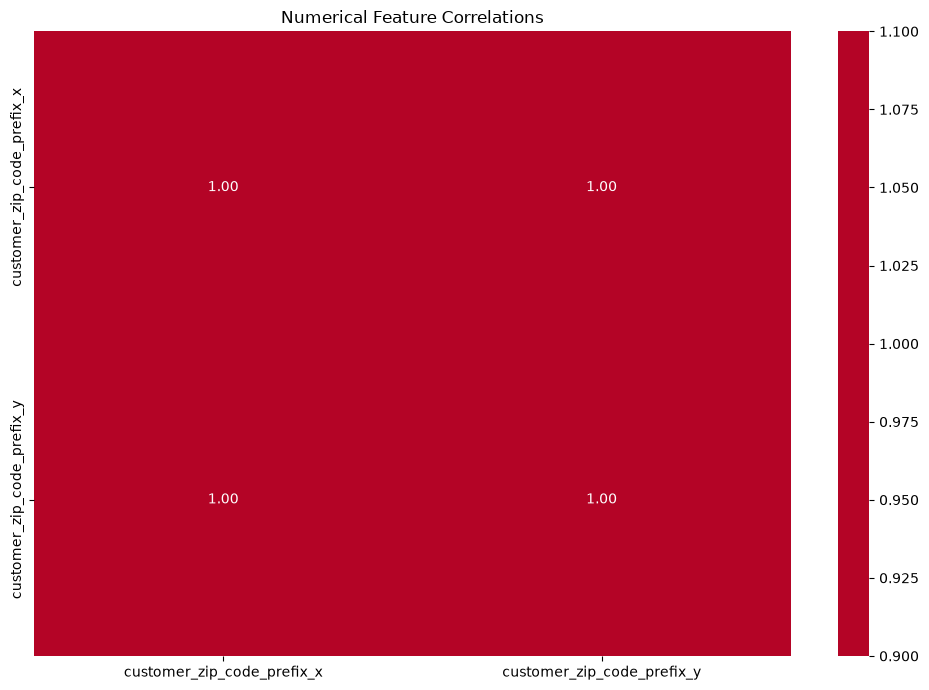

In [18]:
corr_cols = [col for col in plot_cols if train_df[col].nunique(dropna=True) > 1]

if len(corr_cols) >= 2:
    corr = train_df[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Numerical Feature Correlations")
    plt.tight_layout()
    plt.savefig(eda_dir / "correlation_heatmap.png")
    plt.show()
    plt.close()

Purchase date range:
2016-10-03 22:31:31 to 2018-08-29 15:00:37


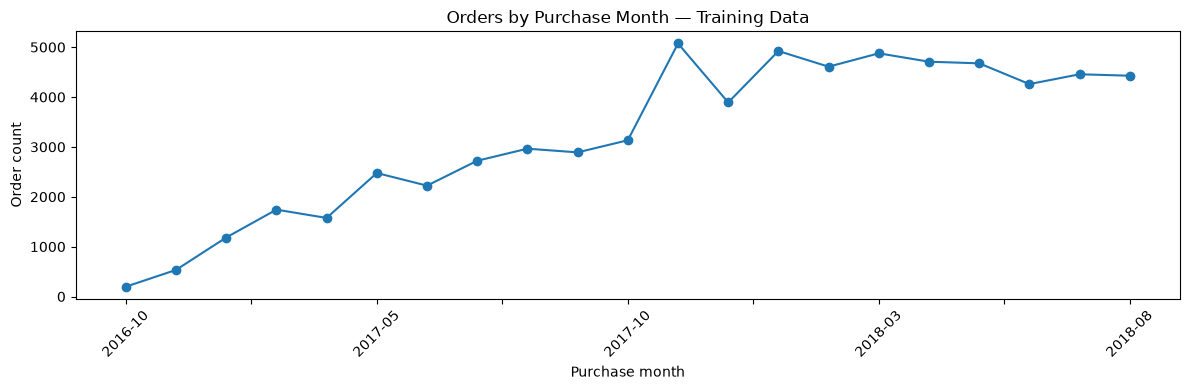

In [19]:
date_col = "order_purchase_timestamp"

train_df[date_col] = pd.to_datetime(train_df[date_col], errors="coerce")

print("Purchase date range:")
print(train_df[date_col].min(), "to", train_df[date_col].max())

train_df["purchase_month"] = train_df[date_col].dt.to_period("M").astype(str)
train_df["purchase_weekday"] = train_df[date_col].dt.day_name()
train_df["purchase_hour"] = train_df[date_col].dt.hour

monthly_orders = train_df.groupby("purchase_month").size()

plt.figure(figsize=(12, 4))
monthly_orders.plot(kind="line", marker="o")
plt.title("Orders by Purchase Month — Training Data")
plt.xlabel("Purchase month")
plt.ylabel("Order count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(eda_dir / "orders_by_month.png")
plt.show()
plt.close()

,count,mean,late_percent
purchase_weekday,,,
Monday,10882,0.089138,8.91
Tuesday,10897,0.085987,8.60
Wednesday,10608,0.076452,7.65
Thursday,10023,0.074628,7.46
Friday,9687,0.085888,8.59
Saturday,7344,0.075980,7.60
Sunday,8092,0.076990,7.70


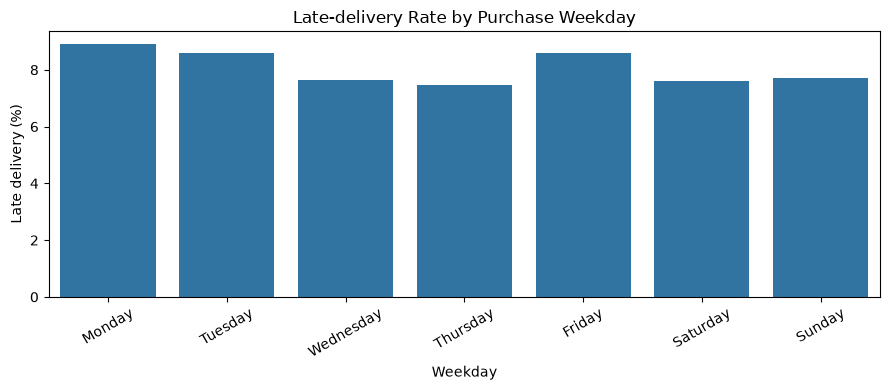

In [20]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_rate = (
    train_df.groupby("purchase_weekday")["late_delivery"]
    .agg(["count", "mean"])
    .reindex(weekday_order)
)

weekday_rate["late_percent"] = (weekday_rate["mean"] * 100).round(2)

display(weekday_rate)

plt.figure(figsize=(9, 4))
sns.barplot(x=weekday_rate.index, y=weekday_rate["late_percent"])
plt.title("Late-delivery Rate by Purchase Weekday")
plt.ylabel("Late delivery (%)")
plt.xlabel("Weekday")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(eda_dir / "late_rate_weekday.png")
plt.show()
plt.close()

,count,mean,late_percent
purchase_hour,,,
0,1655,0.091843,9.18
1,780,0.089744,8.97
2,340,0.073529,7.35
3,182,0.043956,4.40
4,142,0.042254,4.23
5,140,0.085714,8.57
6,335,0.080597,8.06
7,837,0.084827,8.48
8,2024,0.078557,7.86


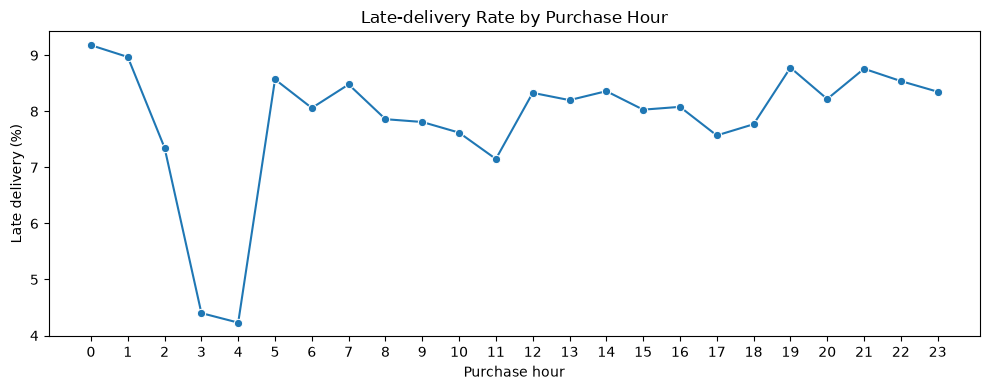

In [21]:
hourly_rate = train_df.groupby("purchase_hour")["late_delivery"].agg(["count", "mean"])

hourly_rate["late_percent"] = (hourly_rate["mean"] * 100).round(2)

display(hourly_rate)

plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly_rate, x=hourly_rate.index, y="late_percent", marker="o")
plt.title("Late-delivery Rate by Purchase Hour")
plt.xlabel("Purchase hour")
plt.ylabel("Late delivery (%)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(eda_dir / "late_rate_hour.png")
plt.show()
plt.close()

In [22]:
geo_col = "customer_state"

if geo_col in train_df.columns:
    state_summary = (
        train_df.groupby(geo_col, dropna=False)["late_delivery"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "late_rate"})
    )

    state_summary["late_percent"] = (state_summary["late_rate"] * 100).round(2)

    state_summary = state_summary.sort_values("late_percent", ascending=False)

    display(state_summary)

    state_plot = state_summary[state_summary["count"] >= 100]

    plt.figure(figsize=(10, 7))
    sns.barplot(data=state_plot.reset_index(), x="late_percent", y=geo_col)
    plt.title("Late-delivery Rate by Customer State")
    plt.xlabel("Late delivery (%)")
    plt.ylabel("Customer state")
    plt.tight_layout()
    plt.savefig(eda_dir / "late_rate_customer_state.png")
    plt.show()
    plt.close()
else:
    print(f"{geo_col} is not present in the training table.")

customer_state is not present in the training table.


In [23]:
missing_summary.to_csv(eda_dir / "missing_summary.csv")
numeric_summary.to_csv(eda_dir / "numeric_summary.csv")
outlier_summary.to_csv(eda_dir / "outlier_summary.csv", index=False)
categorical_summary.to_csv(eda_dir / "categorical_summary.csv")

print("EDA summary tables saved to:", eda_dir)
print("Charts saved to:", eda_dir)

EDA summary tables saved to: ..\artifacts\eda
Charts saved to: ..\artifacts\eda


In [24]:
findings = """
Notebook 4 — EDA Findings

Dataset:
- Training rows:
- Number of columns:
- Target class balance:

Data quality:
- Columns with missing values:
- Important data type issues:
- Duplicate or inconsistent categories:

Numerical features:
- Notable skewed distributions:
- Potential outliers:
- Features with unusual ranges:

Categorical features:
- High-cardinality columns:
- Rare categories:
- Categories with different late-delivery rates:

Date patterns:
- Purchase date range:
- Monthly/weekday/hour patterns:

Geography:
- Geographic patterns observed:

Potential features for Notebook 5:
- Candidate features available at prediction time:
- Features requiring transformation or encoding:

Leakage risks:
- Columns that should not be used as model inputs:
- Other prediction-time concerns:

Conclusion:
- Key findings that will guide feature engineering:
"""

(eda_dir / "eda_findings.txt").write_text(findings, encoding="utf-8")

print("Created:", eda_dir / "eda_findings.txt")

Created: ..\artifacts\eda\eda_findings.txt
